## **Layer 2 : Signal and Edge Extraction**

In [4]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
import pandas as pd
import seaborn as sns
import pandas_ta as ta

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [5]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to sys.path to allow importing from pipeline
# This setup assumes the notebook is in a subdirectory like 'layers/'
current_working_dir = os.getcwd()
if os.path.basename(current_working_dir) == "layers":
    PROJECT_ROOT = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    PROJECT_ROOT = current_working_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define data path (assuming data/market_features.parquet is in project root/data)
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
PROCESSED_DATA_FILE = os.path.join(DATA_DIR, "market_features.parquet")

print(f"Project root set to: {PROJECT_ROOT}")
print(f"Attempting to load data from: {PROCESSED_DATA_FILE}")

try:
    market_data_df = pd.read_parquet(PROCESSED_DATA_FILE)
    print(f"Successfully loaded processed data from {PROCESSED_DATA_FILE}")
except FileNotFoundError:
    print(f"Error: Processed data file not found at {PROCESSED_DATA_FILE}")
    print(
        "Please ensure Layer 1 has been run and the feature pipeline in "
        "'pipeline/feature_pipeline.py' has generated the data."
    )
    market_data_df = pd.DataFrame()

# Display first few rows to confirm data loading and regime column
print("\nDataFrame Head (with regime):")
if not market_data_df.empty:
    print(market_data_df[['datetime', 'close', 'regime']].head())
else:
    print("DataFrame is empty, cannot display head.")

Project root set to: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Attempting to load data from: /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet
Successfully loaded processed data from /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet

DataFrame Head (with regime):
                   datetime       close               regime
0 2026-01-12 14:43:00+00:00  257.140015              Unknown
1 2026-01-12 14:44:00+00:00  257.549988  Downtrend - Impulse
2 2026-01-12 14:45:00+00:00  257.774994    Downtrend - Rally
3 2026-01-12 14:46:00+00:00  258.200012    Downtrend - Rally
4 2026-01-12 14:47:00+00:00  258.109985    Downtrend - Rally


In [6]:
def generate_signals(df):
    """
    Generates a directional trading signal based on the market regime.
    
    This function translates the context from Layer 1 into a simple
    'Bullish', 'Bearish', or 'Neutral' signal for Layer 3 to act on.
    """
    # Create a new 'signal' column, defaulting to 'Neutral'
    signals = pd.Series(index=df.index, dtype=str, name='signal').fillna('Neutral')

    # --- Signal Logic based on Layer 1 Regimes ---

    # Bullish signal: Conditions are favorable for a long position.
    # This is a classic "buy the dip" strategy in a primary uptrend.
    signals[df['regime'] == 'Uptrend - Pullback'] = 'Bullish'

    # Bearish signal: Conditions are favorable for a short position or selling
    # This is a "sell the rip" strategy in a primary downtrend.
    signals[df['regime'] == 'Downtrend - Rally'] = 'Bearish'

    # (Optional) You could also generate signals on impulse moves if your 
    # strategy was trend-following.
    # signals[ df['regime'] == 'Uptrend - Impulse' ] = 'Bullish'
    # signals[ df['regime'] == 'Downtrend - Impulse' ] = 'Bearish'
    
    # Neutral signal: Explicitly set for Ranging, or if no other signal is triggered.
    # signals[ df['regime'] == 'Ranging' ] = 'Neutral' # Already handled by fillna('Neutral')

    return signals

# --- Apply the Signal Generator ---
if not market_data_df.empty and 'regime' in market_data_df.columns:
    market_data_df['signal'] = generate_signals(market_data_df)
else:
    print(
        "Cannot generate signals: market_data_df is empty or 'regime' column "
        "is missing. Please ensure Layer 1 has been run."
    )


Signal Counts:
signal
Neutral    319
Bearish     29
Bullish     29
Name: count, dtype: int64

Latest data with regimes and signals:
                     datetime       close               regime   signal
367 2026-01-12 20:50:00+00:00  260.339996  Downtrend - Impulse  Neutral
368 2026-01-12 20:51:00+00:00  260.420013  Downtrend - Impulse  Neutral
369 2026-01-12 20:52:00+00:00  260.375000  Downtrend - Impulse  Neutral
370 2026-01-12 20:53:00+00:00  260.369995  Downtrend - Impulse  Neutral
371 2026-01-12 20:54:00+00:00  260.325012  Downtrend - Impulse  Neutral
372 2026-01-12 20:55:00+00:00  260.089996  Downtrend - Impulse  Neutral
373 2026-01-12 20:56:00+00:00  260.149994  Downtrend - Impulse  Neutral
374 2026-01-12 20:57:00+00:00  260.230011  Downtrend - Impulse  Neutral
375 2026-01-12 20:58:00+00:00  260.230011  Downtrend - Impulse  Neutral
376 2026-01-12 20:59:00+00:00  260.209991  Downtrend - Impulse  Neutral


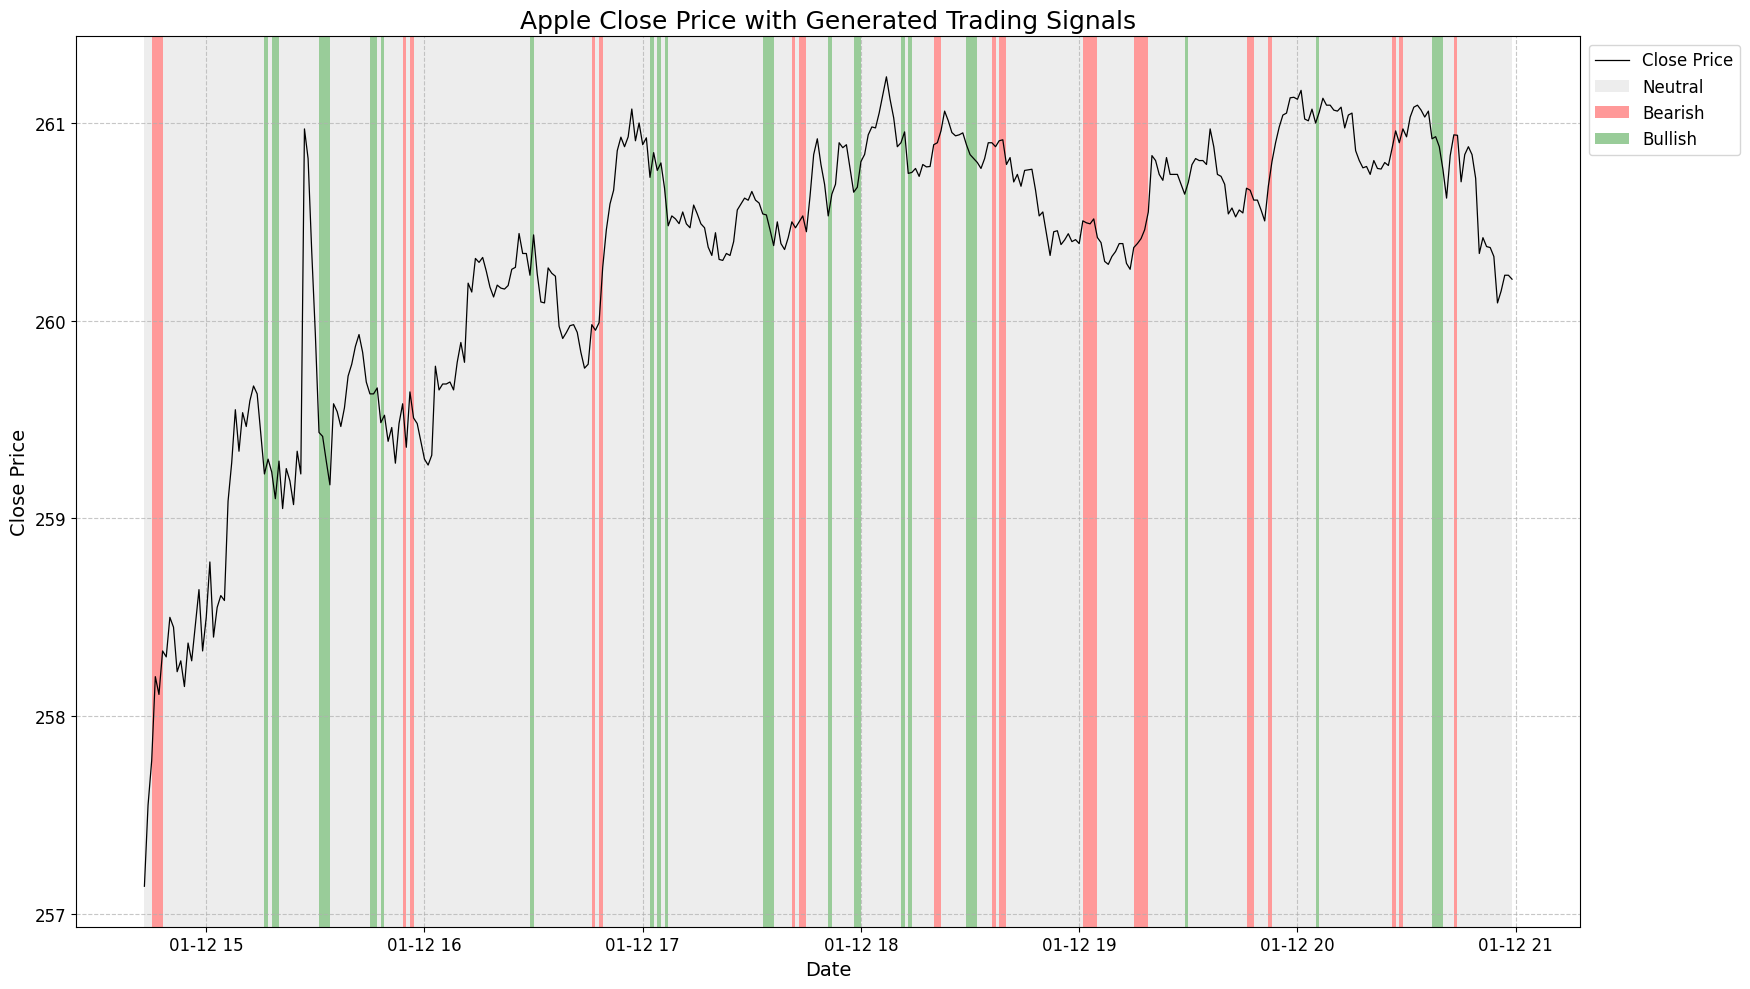

In [7]:
if not market_data_df.empty and 'signal' in market_data_df.columns:
    print("\nSignal Counts:")
    print(market_data_df['signal'].value_counts())

    print("\nLatest data with regimes and signals:")
    print(market_data_df[['datetime', 'close', 'regime', 'signal']].tail(10))

    # Basic visualization of signals (similar to regime visualization)
    df_plot = market_data_df.dropna(subset=['signal']).copy()
    
    signal_colors = {
        'Bullish': 'green',
        'Bearish': 'red',
        'Neutral': 'lightgray'
    }

    plt.figure(figsize=(20, 10))
    ax = plt.gca()

    ax.plot(df_plot['datetime'], df_plot['close'], color='black', label='Close Price', linewidth=0.9)

    current_signal = None
    start_date = None

    for index, row in df_plot.iterrows():
        if current_signal is None:
            current_signal = row['signal']
            start_date = row['datetime']
        elif row['signal'] != current_signal:
            end_date = row['datetime']
            ax.axvspan(
                start_date, 
                end_date, 
                facecolor=signal_colors.get(current_signal, 'white'), 
                alpha=0.4,
                label=f'{current_signal}' if f'{current_signal}' not in 
                [l.get_label() for l in ax.get_legend_handles_labels()[0]] else ""
            )
            current_signal = row['signal']
            start_date = row['datetime']

    if start_date is not None and current_signal is not None:
        ax.axvspan(
            start_date, 
            df_plot['datetime'].iloc[-1], 
            facecolor=signal_colors.get(current_signal, 'white'), 
            alpha=0.4,
            label=f'{current_signal}' if f'{current_signal}' not in 
            [l.get_label() for l in ax.get_legend_handles_labels()[0]] else ""
        )

    plt.title('Apple Close Price with Generated Trading Signals', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Close Price', fontsize=14)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()
else:
    print("Cannot visualize signals: market_data_df is empty or 'signal' column is missing.")

## **Backtracking and Performance Analysis**

In [8]:
print("Calculating ADX as a benchmark...")
market_data_df.ta.adx(append=True)

Calculating ADX as a benchmark...


,ADX_14,ADXR_14_2,DMP_14,DMN_14
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
372,27.894495,25.677669,9.604967,33.705405
373,30.089169,27.924471,9.041949,34.659993
374,30.855902,29.375199,13.315979,31.688249
375,31.481706,30.785437,12.902851,29.833963


Generating comparison plot...


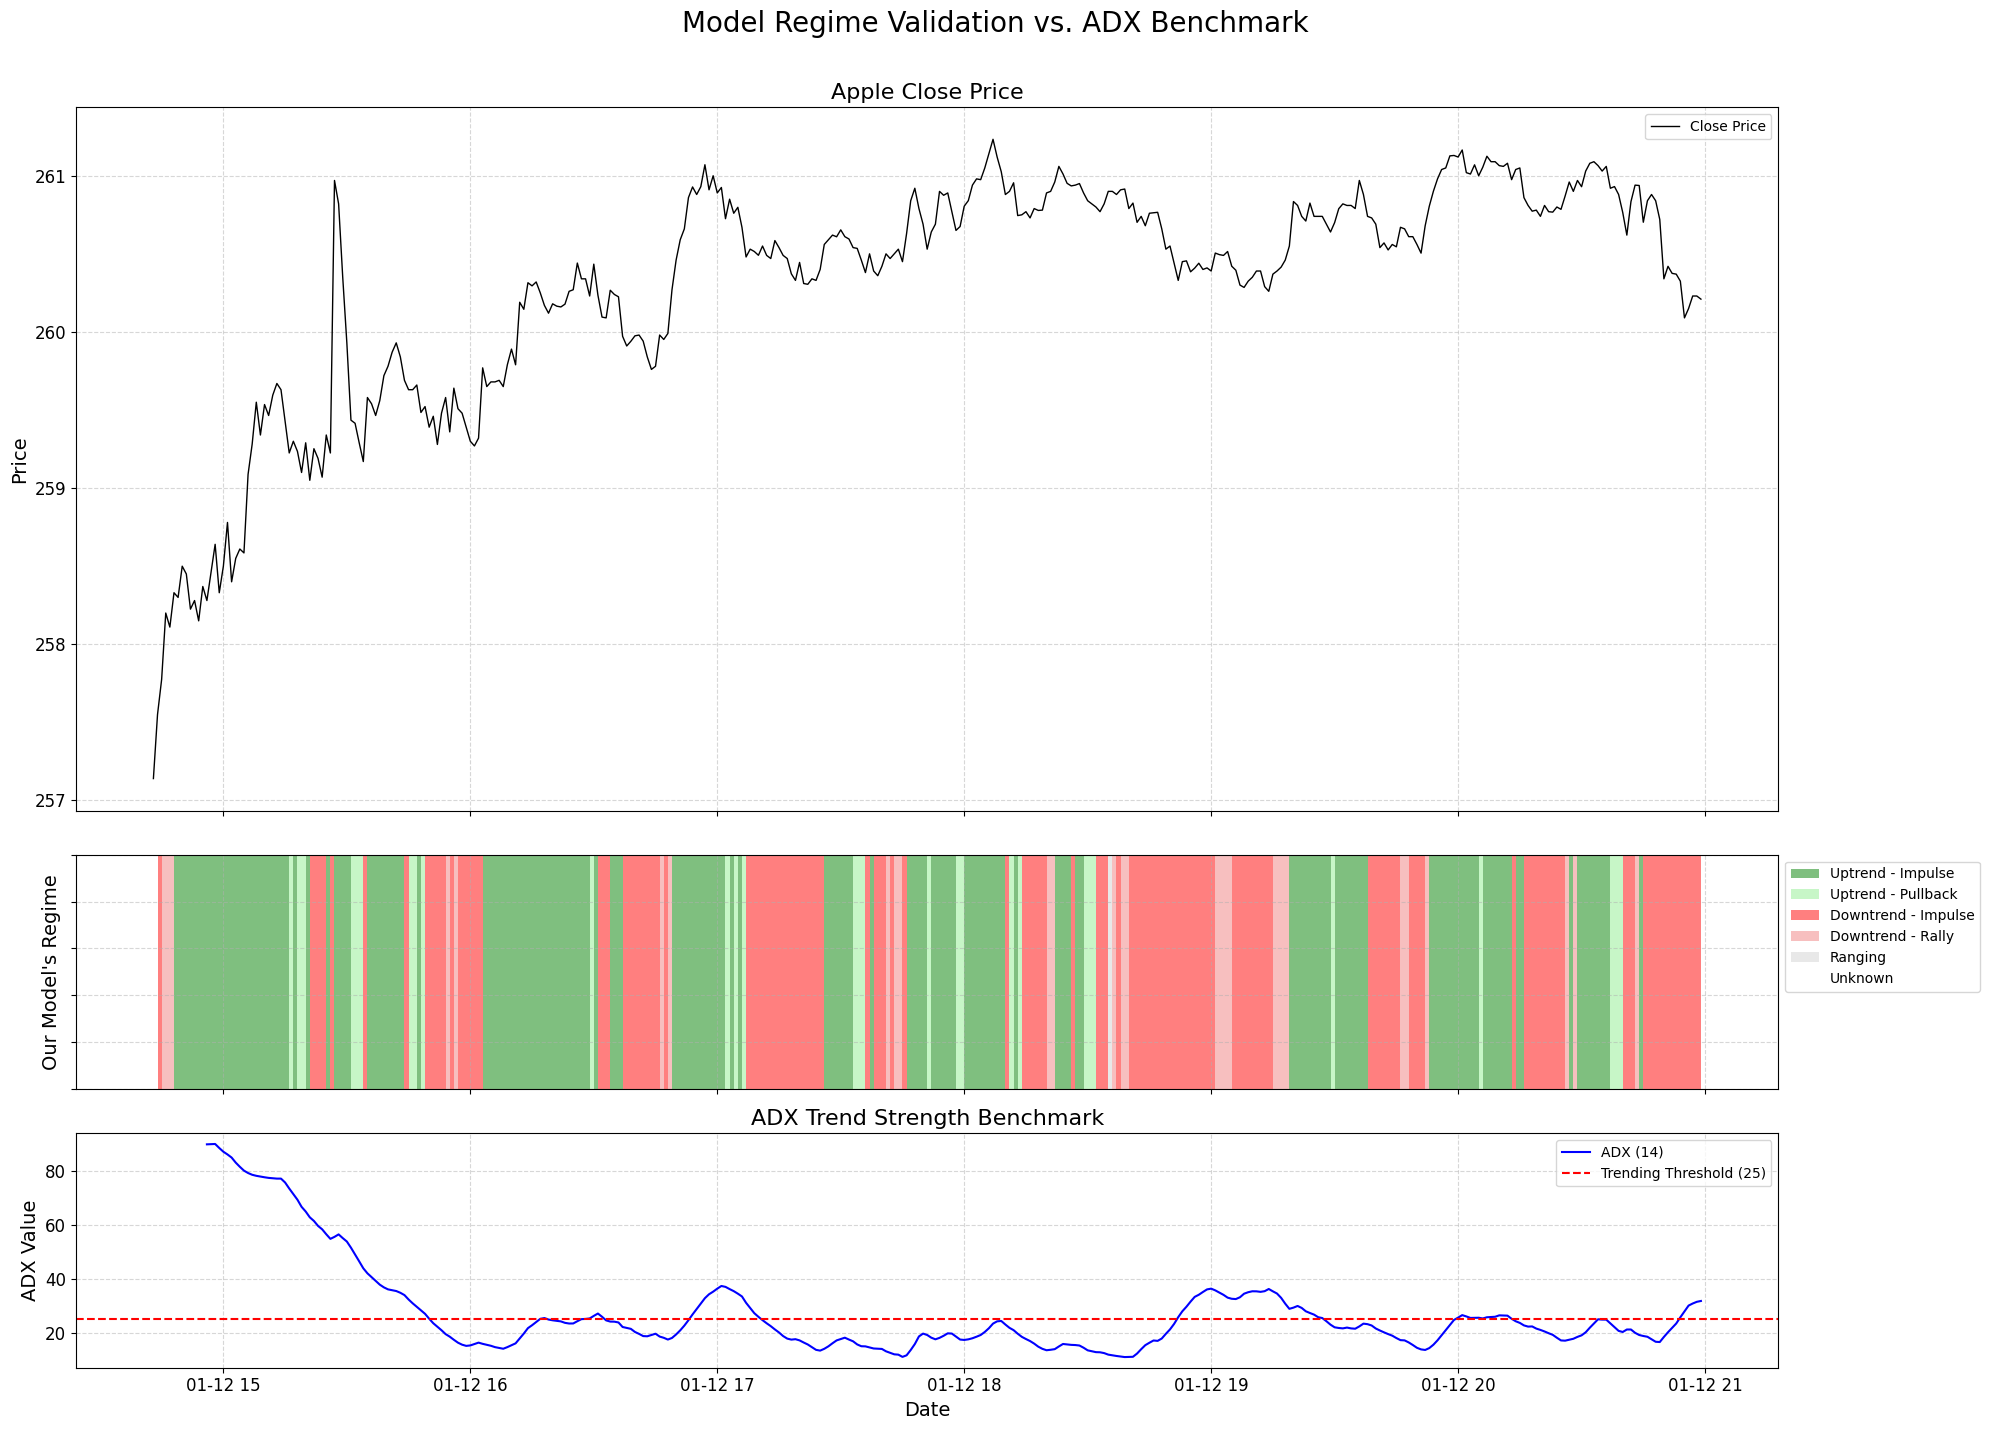

In [9]:
print("Generating comparison plot...")

# Create a figure with three subplots sharing the same X-axis
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, 
    figsize=(20, 15), 
    sharex=True, 
    gridspec_kw={'height_ratios': [3, 1, 1]}
)

fig.suptitle('Model Regime Validation vs. ADX Benchmark', fontsize=20)

# --- Plot 1: Price ---
ax1.plot(
    market_data_df['datetime'], 
    market_data_df['close'], 
    color='black', 
    label='Close Price', 
    linewidth=1
)
ax1.set_ylabel('Price', fontsize=14)
ax1.set_title('Apple Close Price', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

from matplotlib.patches import Patch

df_plot = market_data_df.dropna(subset=['regime']).copy()

regime_colors = {
    'Uptrend - Impulse': 'green', 
    'Uptrend - Pullback': 'lightgreen',
    'Downtrend - Impulse': 'red', 
    'Downtrend - Rally': 'lightcoral',
    'Ranging': 'lightgray', 
    'Unknown': 'white'
}

current_regime = None
start_date = None

# Loop to draw vertical spans for each regime period
for index, row in df_plot.iterrows():
    if current_regime is None or row['regime'] != current_regime:
        if start_date is not None:
            ax2.axvspan(
                start_date, 
                row['datetime'], 
                facecolor=regime_colors.get(current_regime, 'white'), 
                alpha=0.5
            )
        current_regime = row['regime']
        start_date = row['datetime']

# Draw the final span for the last observed regime
if start_date is not None:
    ax2.axvspan(
        start_date, 
        df_plot['datetime'].iloc[-1], 
        facecolor=regime_colors.get(current_regime, 'white'), 
        alpha=0.5
    )

ax2.set_ylabel("Our Model's Regime", fontsize=14)
ax2.set_yticklabels([])  # Hide the y-axis ticks since the colors represent the data
ax2.grid(True, linestyle='--', alpha=0.5)

# Create custom legend for regimes using Matplotlib Patches
legend_elements = [
    Patch(facecolor=color, alpha=0.5, label=regime) 
    for regime, color in regime_colors.items() 
    if regime in df_plot['regime'].unique()
]
ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

# --- Plot 3: ADX Benchmark ---
ax3.plot(
    market_data_df['datetime'], 
    market_data_df['ADX_14'], 
    label='ADX (14)', 
    color='blue'
)

# Add a horizontal line at 25, the common threshold for a "trending" market
ax3.axhline(25, color='red', linestyle='--', label='Trending Threshold (25)')

ax3.set_ylabel('ADX Value', fontsize=14)
ax3.set_xlabel('Date', fontsize=14)
ax3.set_title('ADX Trend Strength Benchmark', fontsize=16)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent title overlap and provide room for labels
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()